# Unidad 1 · Cartas de control X̄–R

**Planta:** Conservas del Itata S.A. — llenado del formato de 480 g
**Datos:** `DatosClases/1_Calidad/itata_peso.csv` (30 subgrupos de n = 4)

---

## Qué se decide aquí

Una carta de control responde **una** pregunta: ¿lo que acabo de observar es
la variación de siempre, o algo cambió? De esa respuesta cuelga una decisión
cara: intervenir la máquina o dejarla trabajar.

Las dos formas de equivocarse tienen nombre:

| | el proceso está bien | el proceso cambió |
|---|---|---|
| **intervengo** | *sobreajuste* (tampering) | correcto |
| **no intervengo** | correcto | causa especial sin detectar |

El sobreajuste no es inocuo: reaccionar a ruido **agrega** variación. Por eso
los límites no se ponen a ojo ni se copian de la especificación del cliente:
se calculan de manera que la alarma falsa tenga una tasa conocida.

## Las dos fases

* **Fase I** (subgrupos 1–20): el proceso se supone estable y se usa para
  *estimar* los límites. Si aquí hay puntos fuera, no se "corrige el punto":
  se investiga y, si hay causa asignable documentada, se excluye y se
  recalcula.
* **Fase II** (subgrupos 21–30): los límites quedan **congelados** y se
  monitorea contra ellos. Recalcular los límites en Fase II con los datos
  nuevos es el error que hace que una carta nunca detecte nada: el
  corrimiento se absorbe dentro de los propios límites.

## Cifras de referencia

| cantidad | valor |
|---|---|
| X̄̄ (Fase I) | 485,794 g |
| R̄ (Fase I) | 7,526 g |
| LCS / LCI de X̄ | 491,28 / 480,31 |
| σ̂ = R̄/d₂ | 3,655 g |
| fuera de control en Fase II | subgrupos 26, 28, 29, 30 |

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from comun import datos, tabla, figura, resumen, verificar, estilo

estilo()

peso = pd.read_csv(datos("1_Calidad", "itata_peso.csv"))
print(f"{len(peso)} mediciones · {peso.subgrupo.nunique()} subgrupos · "
      f"n = {peso.groupby('subgrupo').size().iloc[0]} por subgrupo")
peso.head()

120 mediciones · 30 subgrupos · n = 4 por subgrupo


,subgrupo,fase,turno,n_obs,peso_g
0,1,I,A (06-14),1,475.15
1,1,I,A (06-14),2,478.34
2,1,I,A (06-14),3,488.49
3,1,I,A (06-14),4,491.77
4,2,I,B (14-22),1,489.36


## 1. De mediciones a subgrupos

La carta no trabaja con mediciones sueltas sino con **subgrupos racionales**:
unidades tomadas juntas, de modo que dentro del subgrupo solo actúe la
variación de causa común. Esa es la elección que decide si la carta sirve:
si el subgrupo mezcla turnos o máquinas, la variación "de siempre" queda
inflada, los límites se ensanchan y la carta deja de detectar nada.

De cada subgrupo se resumen dos cosas: dónde está centrado (X̄) y cuánto se
dispersa (R). Se necesitan **las dos** cartas, porque un proceso puede
mantener la media y estar abriéndose.

In [2]:
NOMINAL, LIE, LSE = 480.0, 465.0, 495.0
N_FASE1 = 20

sg = (peso.groupby(["subgrupo", "fase"], as_index=False)
          .agg(xbar=("peso_g", "mean"),
               R=("peso_g", lambda s: s.max() - s.min()),
               s=("peso_g", "std")))
sg = sg.sort_values("subgrupo").reset_index(drop=True)

fase1 = sg[sg.fase == "I"]
xbb = fase1.xbar.mean()
rbar = fase1.R.mean()

print(f"Fase I: {len(fase1)} subgrupos")
print(f"  X-doble-barra = {xbb:.3f} g")
print(f"  R-barra       = {rbar:.3f} g")
sg.head()

Fase I: 20 subgrupos
  X-doble-barra = 485.794 g
  R-barra       = 7.526 g


,subgrupo,fase,xbar,R,s
0,1,I,483.4375,16.62,7.950377
1,2,I,487.0900,6.34,3.002776
2,3,I,485.8650,6.14,2.669763
3,4,I,484.3275,11.96,5.706881
4,5,I,483.7725,4.25,1.987014


## 2. Los límites, y de dónde salen las constantes

Los límites son «centro ± 3 desviaciones del **estadístico**», no de la
observación individual. Como la media de n observaciones tiene desviación
σ/√n, el ±3σ de X̄ es X̄̄ ± 3σ/√n. Para no tener que estimar σ aparte se usa
el rango: E[R] = d₂σ, de donde σ̂ = R̄/d₂, y todo el ±3σ/√n colapsa en una
sola constante A₂ = 3/(d₂√n) tabulada por n.

Las constantes no son magia: son esa aritmética ya hecha.

In [3]:
CONST = {2: dict(A2=1.880, D3=0.0, D4=3.267, d2=1.128),
         3: dict(A2=1.023, D3=0.0, D4=2.574, d2=1.693),
         4: dict(A2=0.729, D3=0.0, D4=2.282, d2=2.059),
         5: dict(A2=0.577, D3=0.0, D4=2.114, d2=2.326)}

n = int(peso.groupby("subgrupo").size().iloc[0])
c = CONST[n]

lcs_x, lci_x = xbb + c["A2"] * rbar, xbb - c["A2"] * rbar
lcs_r, lci_r = c["D4"] * rbar, c["D3"] * rbar
sigma_corto = rbar / c["d2"]

print(f"Constantes para n = {n}: " +
      "  ".join(f"{k} = {v}" for k, v in c.items()))
print(f"\n  Carta X-barra:  LCI {lci_x:.2f}  |  LC {xbb:.2f}  |  LCS {lcs_x:.2f}")
print(f"  Carta R:        LCI {lci_r:.2f}  |  LC {rbar:.2f}  |  LCS {lcs_r:.2f}")
print(f"\n  sigma_corto = R-barra/d2 = {rbar:.3f}/{c['d2']} = {sigma_corto:.3f} g")

Constantes para n = 4: A2 = 0.729  D3 = 0.0  D4 = 2.282  d2 = 2.059

  Carta X-barra:  LCI 480.31  |  LC 485.79  |  LCS 491.28
  Carta R:        LCI 0.00  |  LC 7.53  |  LCS 17.17

  sigma_corto = R-barra/d2 = 7.526/2.059 = 3.655 g


### Comprobación obligatoria: primero R, después X̄

Si la carta R está fuera de control, los límites de X̄ **no son válidos**:
están calculados a partir de un R̄ que no representa nada estable. El orden
de lectura es siempre dispersión primero, centrado después.

In [4]:
r_fuera = fase1[(fase1.R > lcs_r) | (fase1.R < lci_r)]
x_fuera = fase1[(fase1.xbar > lcs_x) | (fase1.xbar < lci_x)]
print(f"Fase I — fuera de control en R:       "
      f"{'ninguno' if r_fuera.empty else list(r_fuera.subgrupo)}")
print(f"Fase I — fuera de control en X-barra: "
      f"{'ninguno' if x_fuera.empty else list(x_fuera.subgrupo)}")
print("\nLa carta R está en control, así que los límites de X-barra son usables.")

Fase I — fuera de control en R:       ninguno
Fase I — fuera de control en X-barra: ninguno

La carta R está en control, así que los límites de X-barra son usables.


## 3. Fase II con límites congelados

Aquí está el punto de la clase. Los límites vienen de Fase I y **no se
tocan**. Todo lo que aparezca fuera es información sobre el proceso, no sobre
los datos nuevos.

In [5]:
sg["fuera_x"] = (sg.xbar > lcs_x) | (sg.xbar < lci_x)
sg["fuera_r"] = (sg.R > lcs_r) | (sg.R < lci_r)

fase2 = sg[sg.fase == "II"]
alarmas = list(fase2[fase2.fuera_x].subgrupo)

for _, f in fase2.iterrows():
    marca = "  <== FUERA (sobre LCS)" if f.fuera_x else ""
    print(f"  subgrupo {int(f.subgrupo):>3}:  X-barra = {f.xbar:8.2f}{marca}")
print(f"\nSubgrupos fuera de control en Fase II: {alarmas}")

  subgrupo  21:  X-barra =   487.36
  subgrupo  22:  X-barra =   482.34
  subgrupo  23:  X-barra =   486.35
  subgrupo  24:  X-barra =   483.69
  subgrupo  25:  X-barra =   483.70
  subgrupo  26:  X-barra =   492.58  <== FUERA (sobre LCS)
  subgrupo  27:  X-barra =   487.79
  subgrupo  28:  X-barra =   493.65  <== FUERA (sobre LCS)
  subgrupo  29:  X-barra =   494.76  <== FUERA (sobre LCS)
  subgrupo  30:  X-barra =   494.51  <== FUERA (sobre LCS)

Subgrupos fuera de control en Fase II: [26, 28, 29, 30]


## 4. Reglas de racha (Nelson)

Un punto fuera de ±3σ es la regla más conocida y la **más lenta** para un
corrimiento pequeño: si la media se corre 1σ, la probabilidad de que un punto
cualquiera caiga fuera sigue siendo baja, y el proceso puede producir fuera de
especificación durante muchos subgrupos antes de que suene la alarma.

Las reglas de racha existen por eso: cambian «un punto muy raro» por «un
patrón improbable». Se pagan con más alarmas falsas, y esa es exactamente la
discusión que hay que tener antes de activarlas todas.

In [6]:
def reglas_nelson(x, lc, sigma):
    """Reglas 1 a 5 de Nelson. Devuelve {regla: [índices]} (base 0)."""
    x = np.asarray(x, float)
    z = (x - lc) / sigma
    n_ = len(x)
    out = {}

    out["R1: fuera de 3 sigma"] = [i for i in range(n_) if abs(z[i]) > 3]
    out["R2: 9 seguidos al mismo lado"] = [
        i for i in range(8, n_)
        if all(z[i - k] > 0 for k in range(9)) or all(z[i - k] < 0 for k in range(9))]
    out["R3: 6 seguidos creciendo o decreciendo"] = [
        i for i in range(5, n_)
        if all(x[i - k] > x[i - k - 1] for k in range(5))
        or all(x[i - k] < x[i - k - 1] for k in range(5))]
    out["R5: 2 de 3 fuera de 2 sigma"] = [
        i for i in range(2, n_)
        if sum(z[i - k] > 2 for k in range(3)) >= 2
        or sum(z[i - k] < -2 for k in range(3)) >= 2]
    return {k: v for k, v in out.items() if v}


sigma_xbar = sigma_corto / np.sqrt(n)
disparos = reglas_nelson(sg.xbar.values, xbb, sigma_xbar)

for regla, idx in disparos.items():
    print(f"  {regla}: subgrupos {[int(sg.subgrupo.iloc[i]) for i in idx]}")

racha = 0
mejor = 0
for v in fase2.xbar:
    racha = racha + 1 if v > xbb else 0
    mejor = max(mejor, racha)
print(f"\n  Racha máxima consecutiva sobre la línea central en Fase II: {mejor} puntos")

  R1: fuera de 3 sigma: subgrupos [26, 28, 29, 30]
  R5: 2 de 3 fuera de 2 sigma: subgrupos [28, 29, 30]

  Racha máxima consecutiva sobre la línea central en Fase II: 5 puntos


## 5. Las dos cartas

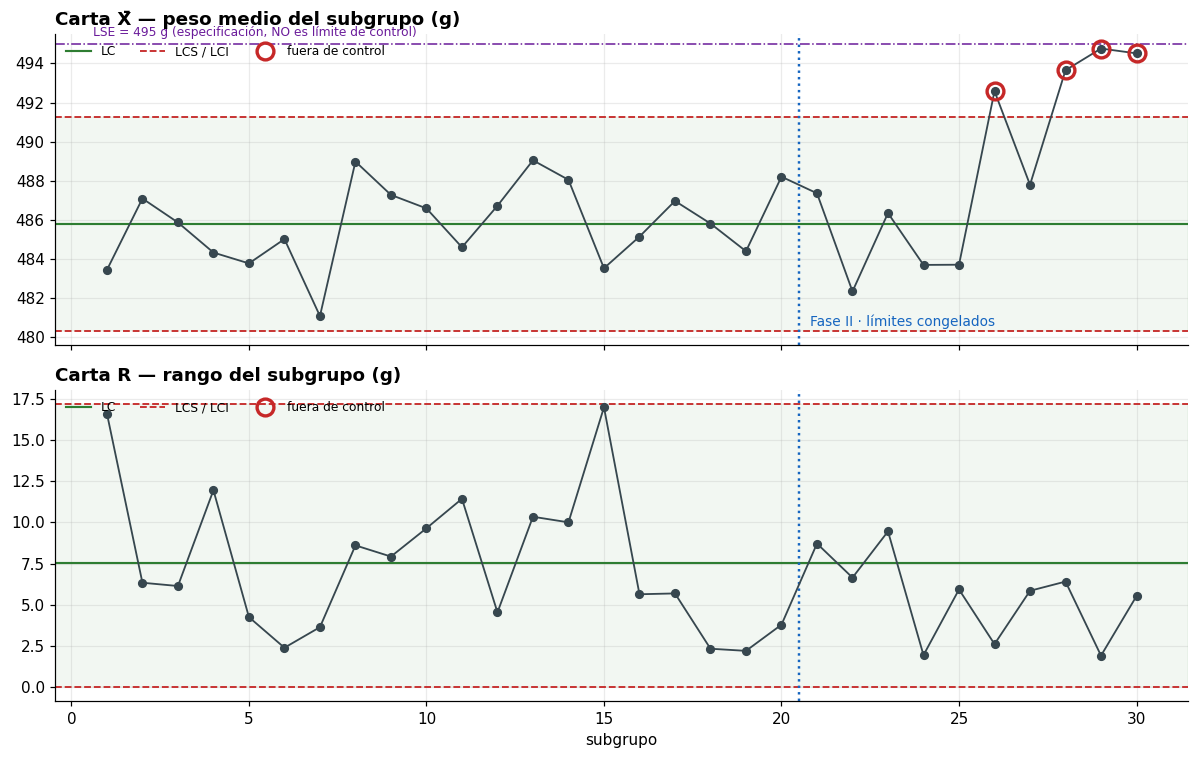

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

for a, col, lc, lcs, lci, tit in [
        (ax[0], "xbar", xbb, lcs_x, lci_x, "Carta X̄ — peso medio del subgrupo (g)"),
        (ax[1], "R", rbar, lcs_r, lci_r, "Carta R — rango del subgrupo (g)")]:
    a.axhspan(lci, lcs, color="#2e7d32", alpha=0.06)
    a.axhline(lc, color="#2e7d32", lw=1.4, label="LC")
    a.axhline(lcs, color="#c62828", lw=1.2, ls="--", label="LCS / LCI")
    a.axhline(lci, color="#c62828", lw=1.2, ls="--")
    a.plot(sg.subgrupo, sg[col], "o-", color="#37474f", ms=5, lw=1.2, zorder=3)
    fuera = sg[sg["fuera_x" if col == "xbar" else "fuera_r"]]
    a.plot(fuera.subgrupo, fuera[col], "o", color="#c62828", ms=11,
           mfc="none", mew=2.2, zorder=4, label="fuera de control")
    a.axvline(N_FASE1 + 0.5, color="#1565c0", lw=1.6, ls=":")
    a.set_title(tit, loc="left")
    a.legend(loc="upper left", ncol=4, fontsize=8)

ax[0].axhline(LSE, color="#6a1b9a", lw=1.0, ls="-.")
ax[0].text(0.6, LSE + 0.4, "LSE = 495 g (especificación, NO es límite de control)",
           color="#6a1b9a", fontsize=8)
ax[0].text(N_FASE1 + 0.8, ax[0].get_ylim()[0] + 1, "Fase II · límites congelados",
           color="#1565c0", fontsize=9)
ax[1].set_xlabel("subgrupo")

figura(fig, "cartas_xbar_r")
plt.show()

El gráfico deja ver la confusión más común del curso: la línea morada es la
**especificación** del cliente y no tiene ninguna relación con los límites de
control, que describen lo que el proceso hace. Un proceso puede estar
perfectamente en control y producir fuera de especificación todo el día: eso
es *capacidad*, y es el tema del cuaderno siguiente.

## 6. Contraste: ¿y si usáramos un detector de anomalías?

La pregunta es legítima, porque ustedes ya vieron métodos no supervisados.
`IsolationForest` detecta observaciones «raras» sin que se le diga qué es
raro. Vale la pena correrlo sobre los mismos datos y comparar.

In [8]:
from sklearn.ensemble import IsolationForest

X = sg[["xbar", "R"]].values
iso = IsolationForest(contamination=0.15, random_state=0).fit(X)
sg["anomalia_iforest"] = iso.predict(X) == -1

comparacion = sg[["subgrupo", "fase", "xbar", "R", "fuera_x", "anomalia_iforest"]]
print(comparacion[comparacion.fuera_x | comparacion.anomalia_iforest]
      .to_string(index=False))

detecta_carta = set(sg[sg.fuera_x].subgrupo)
detecta_iso = set(sg[sg.anomalia_iforest].subgrupo)
print(f"\n  carta de control : {sorted(detecta_carta)}")
print(f"  IsolationForest  : {sorted(detecta_iso)}")
print(f"  solo la carta    : {sorted(detecta_carta - detecta_iso)}")
print(f"  solo el detector : {sorted(detecta_iso - detecta_carta)}")

 subgrupo fase     xbar     R  fuera_x  anomalia_iforest
        1    I 483.4375 16.62    False              True
        7    I 481.0800  3.64    False              True
       15    I 483.5250 17.00    False              True
       26   II 492.5800  2.61     True             False
       28   II 493.6500  6.41     True             False
       29   II 494.7600  1.91     True              True
       30   II 494.5125  5.53     True              True

  carta de control : [26, 28, 29, 30]
  IsolationForest  : [1, 7, 15, 29, 30]
  solo la carta    : [26, 28]
  solo el detector : [1, 7, 15]


### Qué se aprende de la comparación

El resultado es peor de lo que uno esperaría, y conviene mirarlo despacio:

* el detector **no marca los subgrupos 26 ni 28**, que son justamente donde
  empieza el corrimiento;
* en cambio marca los subgrupos **1, 7 y 15**, todos de Fase I, donde el
  proceso estaba estable.

Es decir: se pierde el inicio del evento que importa y da tres alarmas falsas
en la zona tranquila. Las razones son estructurales, no un problema de
calibración:

1. **Hay que decirle de antemano cuánta anomalía espera.** `contamination`
   fija qué fracción se marcará. Con 0,15 marca ~15 % de los subgrupos *pase
   lo que pase*: con un proceso perfectamente estable marcaría igual. La carta
   no tiene ese defecto — su tasa de falsa alarma sale de la distribución del
   estadístico (≈ 0,27 % por punto con ±3σ), no de una elección del analista.
2. **Mira las dos columnas a la vez y sin dirección.** Los subgrupos 1 y 15
   tienen R alto (16,6 y 17,0) y X̄ normal: para el detector son raros; para la
   carta R están dentro de límites, que es la respuesta correcta. Y el
   subgrupo 26, con X̄ = 492,58 pero R = 2,61, le resulta *poco* raro por el
   rango pequeño — exactamente el punto que la carta X̄ está diseñada para
   atrapar.
3. **No distingue Fase I de Fase II.** Aprende de todos los datos,
   corrimiento incluido, así que el corrimiento pasa a formar parte de lo
   «normal» y se auto-enmascara. Es el mismo error que recalcular los límites
   en Fase II, ahora automatizado y más difícil de ver.
4. **La carta dice hacia dónde y desde cuándo.** «La media subió y lleva 5
   puntos sobre la línea central desde el subgrupo 26» es accionable. «Este
   punto es atípico» no lo es.

La conclusión no es que el aprendizaje no supervisado sea inútil, sino que
resuelve otro problema: sirve cuando **no** existe un modelo de la variación
normal ni un estadístico con distribución conocida. En llenado los dos
existen, y renunciar a ellos es cambiar una garantía estadística por una
corazonada — que además, aquí, se equivoca.

## 7. Comprobación contra las cifras de referencia

In [9]:
print("Comprobación:")
ok = [
    verificar(xbb, 485.794, "X-doble-barra (Fase I)"),
    verificar(rbar, 7.526, "R-barra (Fase I)"),
    verificar(lcs_x, 491.28, "LCS de X-barra", tol=1e-2),
    verificar(lci_x, 480.31, "LCI de X-barra", tol=1e-2),
    verificar(sigma_corto, 3.655, "sigma corto plazo"),
    verificar(len(alarmas), 4, "n de subgrupos fuera en Fase II"),
]
print(f"\n{sum(ok)}/{len(ok)} comprobaciones correctas")
assert alarmas == [26, 28, 29, 30], f"se esperaban [26,28,29,30], salió {alarmas}"

tabla(sg, "subgrupos")
resumen({"x_doble_barra": xbb, "R_barra": rbar, "LCS_x": lcs_x, "LCI_x": lci_x,
         "sigma_corto": sigma_corto, "fuera_fase_II": alarmas,
         "racha_maxima": mejor}, "resumen_cartas")
print("\nGuardado en resultados/")

Comprobación:
  [  OK  ] X-doble-barra (Fase I): obtenido 485.7940 | referencia 485.7940 | dif. relativa 0.00e+00
  [  OK  ] R-barra (Fase I): obtenido 7.5260 | referencia 7.5260 | dif. relativa 1.18e-16
  [  OK  ] LCS de X-barra: obtenido 491.2805 | referencia 491.2800 | dif. relativa 9.24e-07
  [  OK  ] LCI de X-barra: obtenido 480.3075 | referencia 480.3100 | dif. relativa 5.11e-06
  [  OK  ] sigma corto plazo: obtenido 3.6552 | referencia 3.6550 | dif. relativa 4.72e-05
  [  OK  ] n de subgrupos fuera en Fase II: obtenido 4.0000 | referencia 4.0000 | dif. relativa 0.00e+00

6/6 comprobaciones correctas

Guardado en resultados/


---

## Para llevarse

1. **Límites de control ≠ especificaciones.** Los primeros describen lo que el
   proceso hace; las segundas, lo que el cliente pide. Compararlos es el tema
   de capacidad, no de control.
2. **Fase I estima, Fase II monitorea.** Recalcular límites en Fase II hace
   que la carta nunca detecte un corrimiento gradual.
3. **Primero la carta R.** Con la dispersión fuera de control, los límites de
   X̄ no significan nada.
4. **Un punto fuera no es la única señal.** Aquí el corrimiento empieza en el
   subgrupo 26 y las rachas lo confirman; el subgrupo 27 vuelve adentro sin
   que el proceso haya vuelto a su sitio.

## Ejercicios

1. Recalcule los límites usando **todos** los 30 subgrupos y vuelva a marcar
   los fuera de control. ¿Cuántos quedan? Explique por qué esto es un error y
   no una mejora.
2. Cambie `contamination` a 0,05 y a 0,30 en `IsolationForest`. ¿Cambia qué
   subgrupos marca? ¿Qué dice eso sobre usarlo como carta de control?
3. El corrimiento real ocurre en el subgrupo 26 y la media pasa de 486 a
   492 g. Con σ̂ = 3,655 y n = 4, calcule la probabilidad de que un subgrupo
   dado caiga sobre el LCS **después** del corrimiento, y con ella el número
   medio de subgrupos hasta la primera alarma (ARL). Compárelo con lo que
   efectivamente pasó.